# Занятие 37. Bagging и случайный лес

Одно дерево понятно, но нестабильно: небольшое изменение данных может полностью изменить верхние вопросы. Объединим много разных деревьев, чтобы ошибки частично компенсировались.


## 1. Ансамбль и bootstrap

**Ансамбль** объединяет несколько моделей.

В bagging каждое дерево получает bootstrap-выборку: из $n$ учебных объектов $n$ раз выбирают объект случайно **с возвращением**. Одни строки повторяются, другие не попадают в выборку.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng=np.random.default_rng(42); objects=np.arange(10)
bootstrap=rng.choice(objects,size=len(objects),replace=True)
oob=np.setdiff1d(objects,np.unique(bootstrap))
print('Bootstrap:',bootstrap)
print('Не попали (OOB):',oob)


Bootstrap: [0 7 6 4 4 8 0 6 2 0]
Не попали (OOB): [1 3 5 9]


In [2]:
# Два дерева на похожих данных могут дать разные правила.
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier

Xd,yd=make_moons(n_samples=180,noise=.28,random_state=42)
idx1=rng.choice(len(Xd),len(Xd),replace=True)
idx2=rng.choice(len(Xd),len(Xd),replace=True)
t1=DecisionTreeClassifier(random_state=1).fit(Xd[idx1],yd[idx1])
t2=DecisionTreeClassifier(random_state=2).fit(Xd[idx2],yd[idx2])
disagreement=np.mean(t1.predict(Xd)!=t2.predict(Xd))
print(f'Деревья не согласны на {disagreement:.1%} объектов')


Деревья не согласны на 8.9% объектов


## 2. Сколько уникальных объектов в bootstrap *

При большом n в bootstrap оказывается примерно 63% уникальных учебных объектов, остальные позиции занимают повторы. Около 37% остаются OOB для конкретного дерева.

Это средние доли, а не точное правило для каждой выборки.


## 3. Bagging

1. Создать много bootstrap-выборок.
2. Независимо обучить модель на каждой.
3. Для регрессии усреднить прогнозы.
4. Для классификации усреднить вероятности или провести голосование.

Слабо связанные случайные ошибки сглаживаются. Bootstrap-выборки пересекаются, поэтому деревья не являются строго независимыми. Если все модели ошибаются одинаково, усреднение не поможет — ансамблю нужно разнообразие.


In [3]:
tree_predictions=np.array([72,80,75,77,71])
print('Прогноз ансамбля:',tree_predictions.mean())
votes=np.array([1,1,0,1,0])
print('Доля голосов класса 1:',votes.mean(),'итоговый класс:',int(votes.mean()>=.5))


Прогноз ансамбля: 75.0
Доля голосов класса 1: 0.6 итоговый класс: 1


Стандартное отклонение одного прогноза: 14.8
Стандартное отклонение среднего 30 прогнозов: 2.8


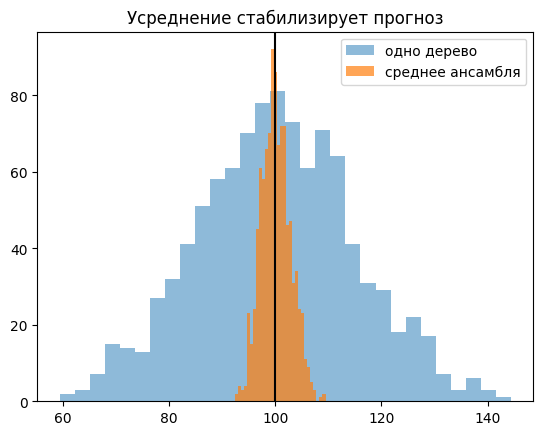

In [4]:
# Разброс среднего меньше разброса отдельного шумного прогноза.
true_value=100
simulated=true_value+rng.normal(0,15,size=(1000,30))
single=simulated[:,0]
ensemble=simulated.mean(axis=1)
print('Стандартное отклонение одного прогноза:',round(single.std(),1))
print('Стандартное отклонение среднего 30 прогнозов:',round(ensemble.std(),1))
plt.hist(single,bins=30,alpha=.5,label='одно дерево')
plt.hist(ensemble,bins=30,alpha=.7,label='среднее ансамбля')
plt.axvline(true_value,color='black'); plt.legend(); plt.title('Усреднение стабилизирует прогноз'); plt.show()


## 4. Разброс и связь ошибок

Усреднение особенно полезно, когда отдельные модели шумны, но их ошибки не полностью совпадают. Чем сильнее ошибки связаны, тем меньше выигрыш.

Random Forest специально уменьшает сходство деревьев случайным выбором признаков.


## 5. Out-of-bag оценка

Около трети объектов не попадает в конкретную bootstrap-выборку. Для каждого учебного объекта можно собрать прогнозы только тех деревьев, которые его не видели. Это **OOB-оценка**.

OOB полезна как дополнительная validation-оценка, но не заменяет отдельный test и подходящее временное или групповое разбиение.


## 6. Как собирается OOB-прогноз

Для объекта берут только деревья, в bootstrap которых он отсутствовал. Их вероятности усредняют и сравнивают с истинным классом.

У разных объектов число доступных OOB-деревьев различается, поэтому слишком маленький лес даёт нестабильную OOB-оценку.


## 7. Случайный лес

Обычные деревья часто выбирают один и тот же сильный признак и становятся похожими. Случайный лес в каждом узле рассматривает случайное подмножество признаков.

Так деревья становятся разнообразнее. Отдельное дерево немного слабеет, но ансамбль часто выигрывает.


In [5]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score

X,y=make_classification(n_samples=1000,n_features=20,n_informative=7,flip_y=.08,random_state=42)
Xt,Xv,yt,yv=train_test_split(X,y,test_size=.3,stratify=y,random_state=42)
models={
 'одно дерево':DecisionTreeClassifier(random_state=42),
 'bagging':BaggingClassifier(n_estimators=150,random_state=42,n_jobs=-1),
 'случайный лес':RandomForestClassifier(n_estimators=150,random_state=42,n_jobs=-1)
}
for name,m in models.items():
 m.fit(Xt,yt)
 print(name,round(accuracy_score(yt,m.predict(Xt)),3),round(accuracy_score(yv,m.predict(Xv)),3))


одно дерево 1.0 0.75


bagging 1.0 0.847


случайный лес 1.0 0.82


## 8. Классификация и регрессия

В регрессии лес усредняет числовые прогнозы деревьев. В классификации sklearn усредняет вероятности классов и выбирает класс с максимальной средней вероятностью.

Это не всегда совпадает с простым голосованием жёстких классов каждого дерева.


## 9. Основные гиперпараметры

- `n_estimators` — число деревьев; больше обычно стабильнее, но медленнее.
- `max_features` — сколько признаков доступно в узле.
- `max_depth`, `min_samples_leaf` — сложность отдельных деревьев.
- `max_samples` — размер bootstrap-выборки, если `bootstrap=True`.

Добавление деревьев обычно не вызывает классическое переобучение, но после стабилизации качества лишь тратит ресурсы.


In [6]:
forest_oob=RandomForestClassifier(n_estimators=300,oob_score=True,random_state=42,n_jobs=-1).fit(Xt,yt)
print('OOB accuracy:',round(forest_oob.oob_score_,3))
print('Validation accuracy:',round(accuracy_score(yv,forest_oob.predict(Xv)),3))


OOB accuracy: 0.853
Validation accuracy: 0.843


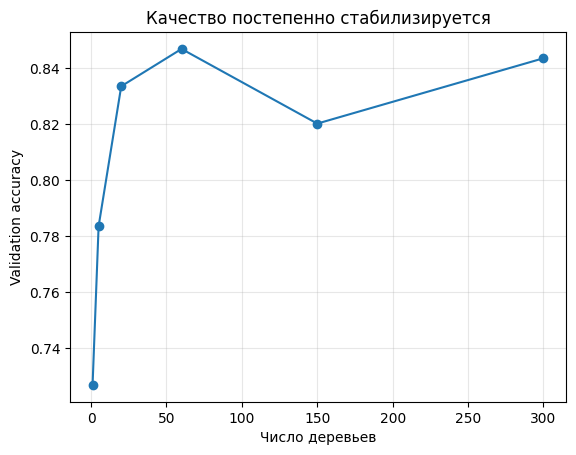

In [7]:
counts=[1,5,20,60,150,300]; scores=[]
for count in counts:
 current=RandomForestClassifier(n_estimators=count,random_state=42,n_jobs=-1).fit(Xt,yt)
 scores.append(accuracy_score(yv,current.predict(Xv)))
plt.plot(counts,scores,marker='o'); plt.xlabel('Число деревьев'); plt.ylabel('Validation accuracy')
plt.title('Качество постепенно стабилизируется'); plt.grid(alpha=.3); plt.show()


## 10. Что настраивать первым

Сначала выбирают достаточно большое n_estimators для стабильности. Затем ограничивают отдельные деревья через min_samples_leaf или max_depth и настраивают max_features.

Параметры сравнивают одним CV-протоколом; OOB может служить быстрым дополнительным ориентиром.


## 11. Метрики при дисбалансе

При редком классе accuracy вводит в заблуждение. Сравнивают precision, recall, F1 и PR-кривую на validation.


## 12. class_weight в Random Forest

`class_weight` меняет веса классов при обучении деревьев. Это другой инструмент, чем смена порога вероятности (п. 13).


Вероятность леса — среднее вероятностей отдельных деревьев. Она не обязана быть хорошо откалибрована: калибровку и выбор порога проверяют отдельно.


## 13. Порог вероятности

Порог меняет превращение средней вероятности в класс. При редком классе сравнивают precision, recall и PR-кривую, а порог выбирают на validation.


## 14. Impurity importance в лесу

Лес усредняет impurity importance по деревьям, но сохраняет её ограничения: коррелирующие признаки могут «делить» важность.


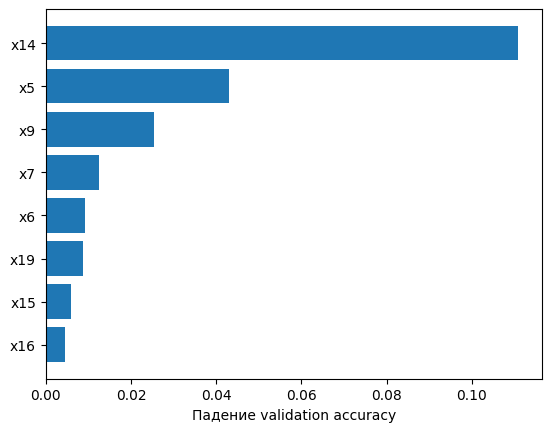

In [8]:
from sklearn.inspection import permutation_importance

perm=permutation_importance(forest_oob,Xv,yv,n_repeats=8,random_state=42,n_jobs=-1)
top=np.argsort(perm.importances_mean)[-8:]
plt.barh([f'x{i}' for i in top],perm.importances_mean[top]); plt.xlabel('Падение validation accuracy'); plt.show()


## 15. Проверка важности на новых данных

Impurity importance вычисляется по train и может предпочитать признаки с множеством порогов. Permutation importance считают на validation после фиксации модели.

Если после просмотра importance изменить признаки, итог снова проверяют по validation, а не по test.


## 16. Bagging, Random Forest и Extra Trees *

- Bagging создаёт разные bootstrap-выборки.
- Random Forest дополнительно ограничивает случайный набор признаков в каждом узле.
- Extra Trees ещё сильнее рандомизирует пороги и по умолчанию использует весь train без bootstrap.

Все методы создают разнообразие по-разному. Extra Trees — факультативный обзор; выбор ансамбля делают по validation.


## 17. Плюсы и ограничения

Лес хорошо работает с нелинейностями и взаимодействиями, мало требует предобработки и устойчивее одного дерева. Деревья можно обучать параллельно.

Ограничения: слабая экстраполяция, менее прозрачное решение, ступенчатые прогнозы. Сотни глубоких деревьев занимают память и замедляют прогноз, поэтому качество и ресурсы оценивают вместе.
